# Gaussian Mixture Model (GMM) Clustering for Airbnb Listings

This notebook demonstrates how Gaussian Mixture Models (GMM) can be used to cluster Airbnb listings 
into marketing archetypes. Unlike K-Means, GMM provides *soft clustering* — each listing has a 
probability of belonging to multiple clusters. This reflects reality, where properties often appeal 
to overlapping customer segments.

In [1]:
# ---------------------------------------------------------
# STEP 1: Setup & Ingestion
# Purpose: Load ML-ready listing features and inspect schema
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Resolve project root (assumes notebook is in /notebooks)
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gold_dir = project_root / "data" / "gold"

# Load ML feature table
df = pd.read_parquet(gold_dir / "ml_listing_features.parquet")

print(f"✅ Loaded {len(df):,} listings")
df.info()
df.head()

✅ Loaded 94,559 listings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94559 entries, 0 to 94558
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id                            94559 non-null  int64         
 1   host_id                       94559 non-null  int64         
 2   room_type                     94559 non-null  category      
 3   neighbourhood_cleansed        94559 non-null  category      
 4   price                         60341 non-null  float64       
 5   host_is_superhost             94559 non-null  int64         
 6   host_response_rate            60416 non-null  Float64       
 7   review_scores_rating          94559 non-null  float64       
 8   beds                          60282 non-null  float64       
 9   accommodates                  94559 non-null  int64         
 10  minimum_nights                94559 non-null  int64         
 11  max

,id,host_id,room_type,neighbourhood_cleansed,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,...,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed,review_scores_rating_imputed
0,91031,491004,Entire home/apt,Wandsworth,94.0,0,88.0,4.23,1.0,2,...,365.0,72.0,99.0,0.802740,25,2011-05-03,2025-03-05,0.148368,1.0,4.23
1,91287,493497,Entire home/apt,Islington,NaN,0,100.0,4.51,NaN,4,...,365.0,0.0,185.0,1.000000,66,2011-05-17,2024-12-04,0.400000,2.0,4.51
2,92352,497172,Entire home/apt,Islington,NaN,1,100.0,4.86,NaN,2,...,365.0,0.0,110.0,1.000000,73,2016-12-11,2024-12-02,0.751802,2.0,4.86
3,92399,497366,Entire home/apt,Islington,86.0,1,100.0,4.84,1.0,2,...,365.0,288.0,100.0,0.210959,317,2011-07-05,2025-02-27,1.907341,1.0,4.84
4,93015,499704,Entire home/apt,Hammersmith and Fulham,175.0,0,<NA>,4.85,3.0,5,...,365.0,33.0,180.0,0.909589,40,2012-02-01,2024-11-14,0.256959,3.0,4.85


In [2]:
# ---------------------------------------------------------
# STEP 2: Initial Data Audit
# Purpose: Check nulls, dtypes, and basic distributions
# ---------------------------------------------------------

# Null counts
nulls = df.isnull().sum().sort_values(ascending=False)
print("🔍 Nulls per column:\n", nulls[nulls > 0])

# Descriptive stats
df.describe().T

# Quick look at categorical flags
print("Unique room types:", df["room_type"].unique())
print("Unique neighbourhoods:", df["neighbourhood_cleansed"].nunique())

🔍 Nulls per column:
 beds                       34277
price                      34218
host_response_rate         34143
last_review_date           24244
first_review_date          24244
future_calendar_days           5
future_available_days          5
estimated_revenue_l365d        5
future_occupancy_rate          5
future_avg_price               5
beds_imputed                   5
dtype: int64
Unique room types: ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Categories (4, object): ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
Unique neighbourhoods: 33


In [3]:
df.describe()

,id,host_id,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,minimum_nights,maximum_nights,...,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed,review_scores_rating_imputed
count,9.455900e+04,9.455900e+04,60341.000000,94559.000000,60416.0,94559.000000,60282.000000,94559.000000,94559.000000,9.455900e+04,...,94554.000000,94554.000000,94554.000000,94554.000000,94559.0,70315,70315,94559.000000,94554.000000,94559.000000
mean,6.066726e+17,2.003118e+08,185.482624,0.177593,92.675401,3.489244,1.932102,3.299337,5.482704,6.215041e+03,...,365.002232,134.234670,269.660089,0.632230,20.434438,2021-08-28 16:12:38.552229120,2023-07-23 08:50:12.500889088,1.422220,1.820209,4.669267
min,1.391300e+04,2.594000e+03,6.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000e+00,...,350.000000,0.000000,0.000000,0.000000,0.0,2009-12-21 00:00:00,2011-07-02 00:00:00,0.000000,1.000000,1.000000
25%,2.809901e+07,2.572771e+07,71.000000,0.000000,99.0,0.000000,1.000000,2.000000,1.000000,6.000000e+01,...,365.000000,0.000000,67.000000,0.263014,0.0,2018-12-30 00:00:00,2023-06-27 00:00:00,0.000000,1.000000,4.630000
50%,7.511326e+17,1.057565e+08,120.000000,0.000000,100.0,4.680000,1.000000,2.000000,2.000000,3.650000e+02,...,365.000000,88.000000,120.000000,0.758904,4.0,2022-12-04 00:00:00,2024-10-31 00:00:00,0.530973,2.000000,4.740000
75%,1.141072e+18,3.760111e+08,197.000000,0.000000,100.0,4.960000,2.000000,4.000000,4.000000,1.125000e+03,...,365.000000,269.000000,200.000000,1.000000,19.0,2024-05-06 00:00:00,2025-02-03 00:00:00,1.714286,2.000000,4.990000
max,1.368871e+18,6.819521e+08,74100.000000,1.000000,100.0,5.000000,50.000000,16.000000,1125.000000,5.248556e+08,...,366.000000,366.000000,80000.000000,1.000000,1791.0,2025-03-14 00:00:00,2025-03-15 00:00:00,90.000000,50.000000,5.000000
std,5.481489e+17,2.068400e+08,604.807337,0.382172,21.114495,2.090986,1.439265,2.063247,23.157895,1.707381e+06,...,0.464565,136.288298,1069.277493,0.373383,48.854875,NaN,NaN,3.202008,1.175600,0.467765


In [3]:
# REMAINING Missingness Cleanup Strategy

#DROP
df = df.drop(columns=[
    "beds",                # replaced by beds_imputed
    "price",               # replaced by future_avg_price
    "first_review_date",   # not needed for clustering
    "last_review_date"     # same
])

df.head()

,id,host_id,room_type,neighbourhood_cleansed,host_is_superhost,host_response_rate,review_scores_rating,accommodates,minimum_nights,maximum_nights,...,number_of_reviews_ltm,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,reviews_per_month,beds_imputed,review_scores_rating_imputed
0,91031,491004,Entire home/apt,Wandsworth,0,88.0,4.23,2,6,89,...,4,25,365.0,72.0,99.0,0.802740,25,0.148368,1.0,4.23
1,91287,493497,Entire home/apt,Islington,0,100.0,4.51,4,1,365,...,4,66,365.0,0.0,185.0,1.000000,66,0.400000,2.0,4.51
2,92352,497172,Entire home/apt,Islington,1,100.0,4.86,2,3,121,...,14,73,365.0,0.0,110.0,1.000000,73,0.751802,2.0,4.86
3,92399,497366,Entire home/apt,Islington,1,100.0,4.84,2,1,365,...,26,317,365.0,288.0,100.0,0.210959,317,1.907341,1.0,4.84
4,93015,499704,Entire home/apt,Hammersmith and Fulham,0,<NA>,4.85,5,5,1125,...,3,40,365.0,33.0,180.0,0.909589,40,0.256959,3.0,4.85


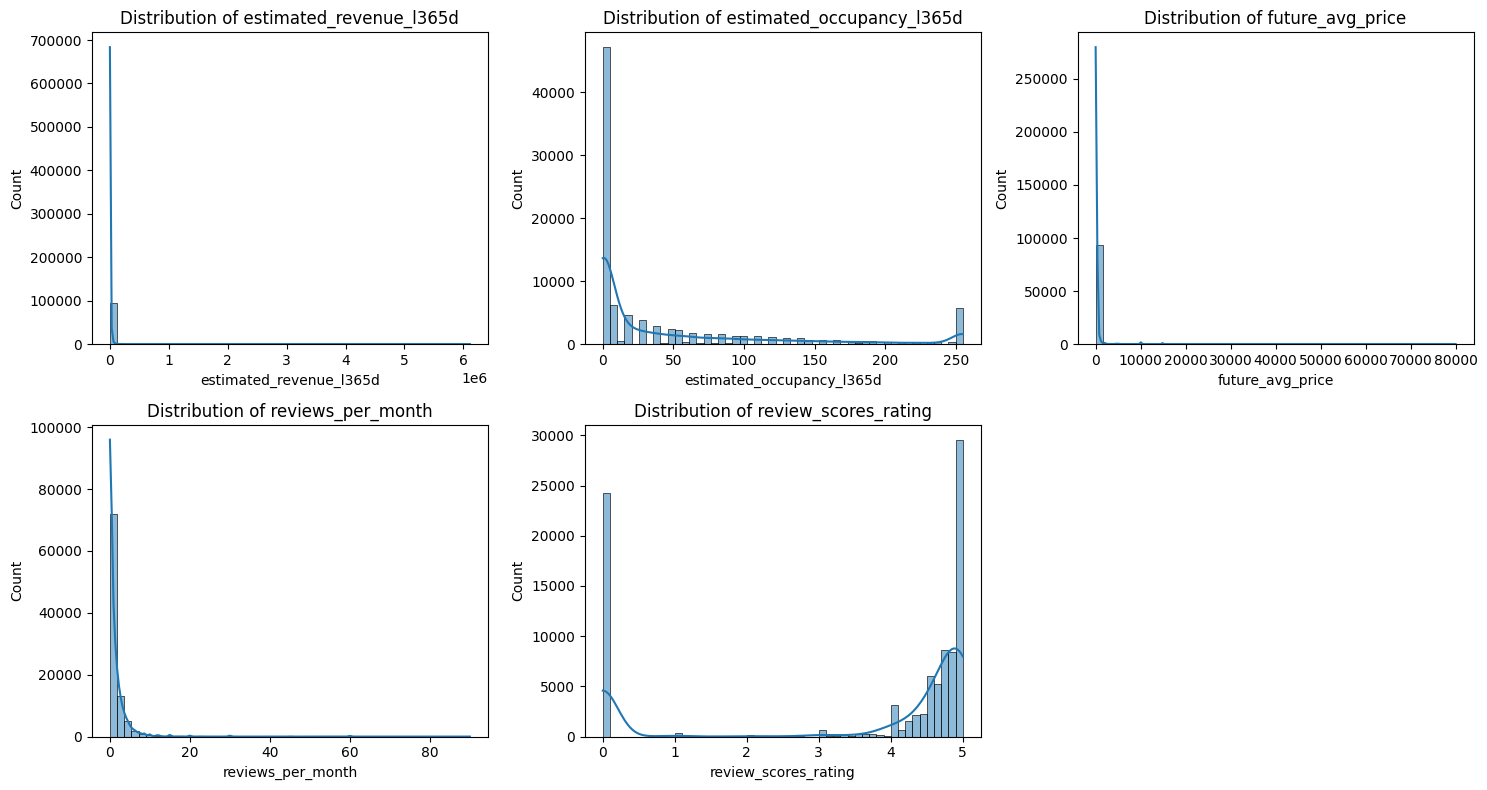

In [4]:
# ---------------------------------------------------------
# STEP 3: EDA - Raw Distributions of Core Features
# Purpose: Inspect main clustering signals before transforms
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

core_features = [
    "estimated_revenue_l365d",   # Annual revenue signal
    "estimated_occupancy_l365d", # Booking frequency
    "future_avg_price",          # Host pricing strategy
    "reviews_per_month",         # Engagement velocity
    "review_scores_rating"       # Guest satisfaction
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(core_features):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 📊 Observations from Raw Feature Distributions

Inspection of the raw distributions of five core features that will likely drive the clustering model:

### 1. `estimated_revenue_l365d`
- **Observation:** Highly right-skewed. Most listings generate modest revenue, with a long tail of high earners.
- **Action:** Apply `log1p` transform to compress the tail and reveal structure in the mid-range. Consider winsorizing extreme values if needed.

### 2. `estimated_occupancy_l365d`
- **Observation:** Majority of listings show low-to-moderate occupancy, but some engineered values are extremely high.
- **Action:** Cap at a sensible threshold (e.g., 99th percentile) to prevent distortion in clustering. No transform needed.

### 3. `future_avg_price`
- **Observation:** Strong skew toward lower prices, with a few listings priced in the tens of thousands.
- **Action:** Apply `log1p` transform to stabilize scale. This helps differentiate pricing strategies without letting outliers dominate.

### 4. `reviews_per_month`
- **Observation:** Most listings receive fewer than 2 reviews/month. A small subset shows high engagement velocity.
- **Action:** Use `log1p` to reveal structure in the low-activity range. This feature helps distinguish high-performing listings.

### 5. `review_scores_rating`
- **Observation:** Bimodal distribution with many listings unrated (0) and many clustered near 5.0.
- **Action:** Treat zeros as missing (not “bad”) to avoid pulling clusters toward a false anchor. No transform needed.

---

These observations guide the preprocessing strategy: log transforms for skewed features, capping for engineered extremes, and careful treatment of missing values. This ensures the clustering model reflects meaningful business variation rather than technical noise.

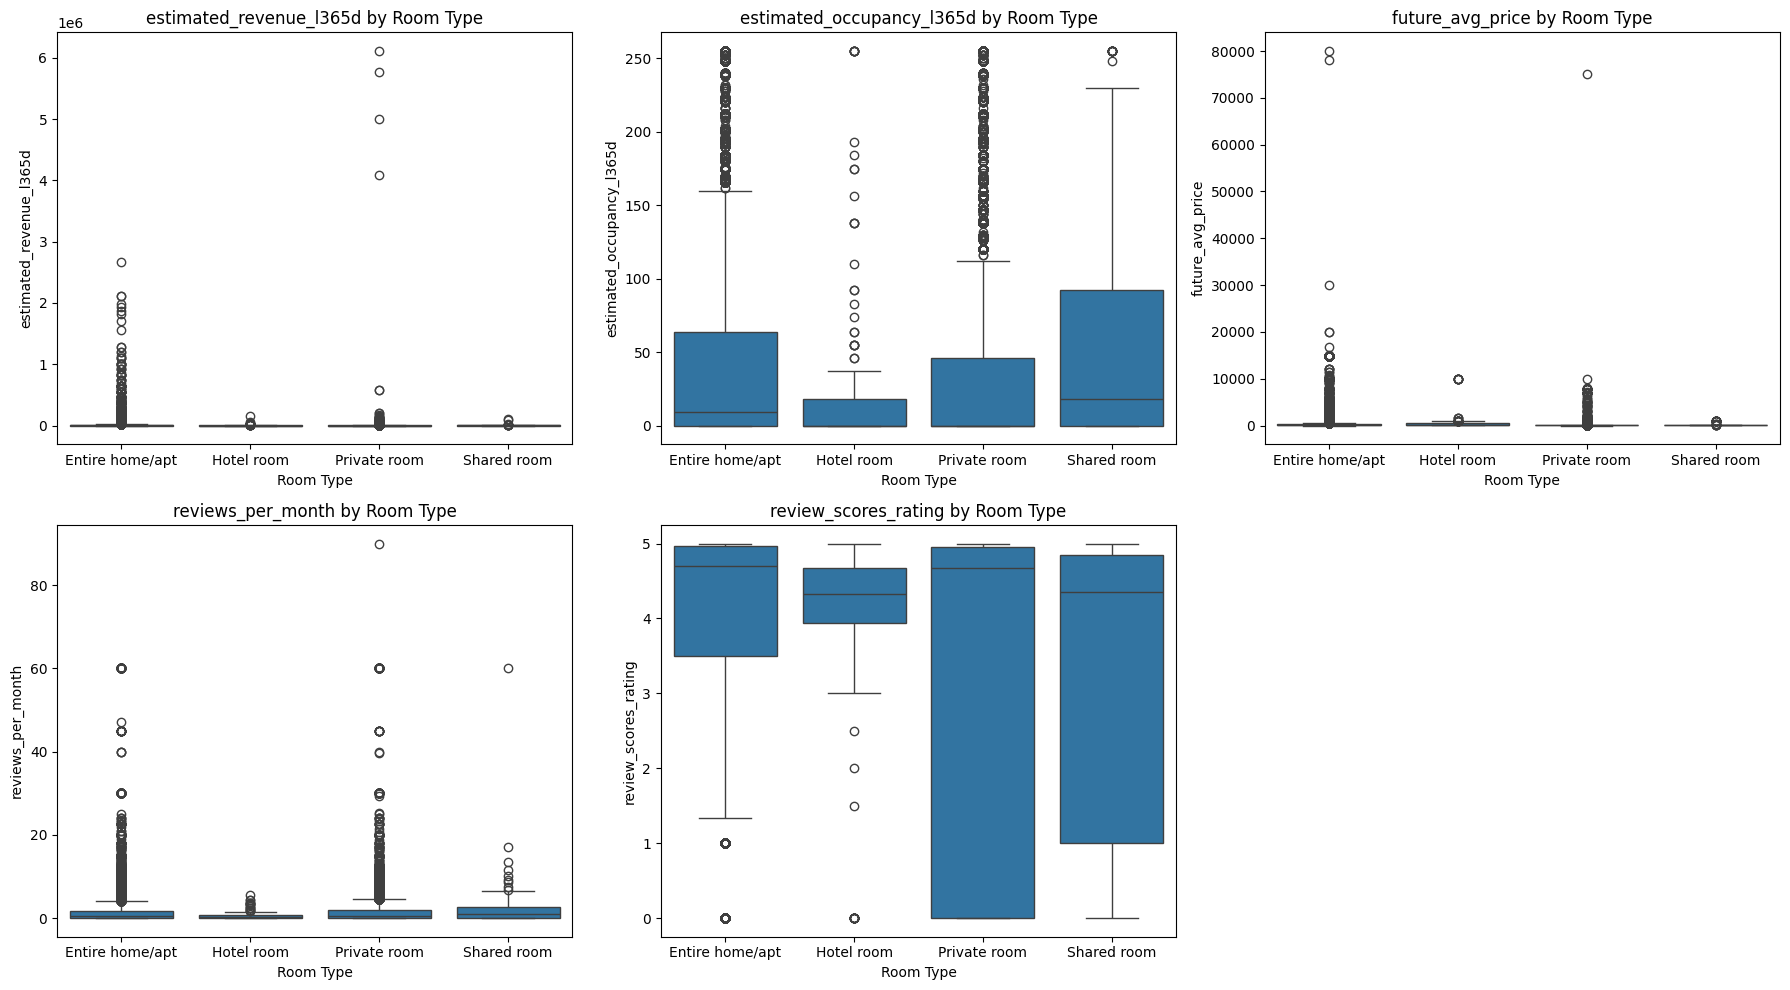

In [5]:
# ---------------------------------------------------------
# STEP 4: EDA - Boxplots by Room Type
# Purpose: Compare feature distributions across room types
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Define core features to plot
core_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Set up plot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot each feature by room type
for i, col in enumerate(core_features):
    sns.boxplot(data=df, x="room_type", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Room Type")
    axes[i].set_xlabel("Room Type")
    axes[i].set_ylabel(col)

# Remove empty subplot
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 📦 Boxplot Analysis by Room Type

Examination of how key performance features vary across room types using boxplots. This helps to understand structural differences and identify outliers that may distort clustering.

### 1. `estimated_revenue_l365d`
- **Observation:** Entire home/apt listings dominate revenue, with a wide spread and extreme outliers. Hotel rooms show high variance but fewer listings.
- **Action:** Apply `log1p` transform to compress the long tail. Consider capping extreme values (e.g., top 0.5%) to stabilize clustering.

### 2. `estimated_occupancy_l365d`
- **Observation:** Entire homes again show the widest spread. Shared and private rooms have tighter distributions. Some extreme values suggest engineered artifacts.
- **Action:** Cap occupancy at a sensible threshold (e.g., 99th percentile). No transform needed unless skew persists post-capping.

### 3. `future_avg_price`
- **Observation:** Hotel rooms and entire homes show higher pricing, but hotel room variance is extreme. Shared rooms are predictably low.
- **Action:** Apply `log1p` transform to normalize pricing. Consider winsorizing hotel room prices to reduce distortion.

### 4. `reviews_per_month`
- **Observation:** Most room types show low review velocity, but hotel rooms and some private rooms have high outliers.
- **Action:** Use `log1p` to reveal structure in low-activity listings. This feature helps distinguish high-engagement properties.

### 5. `review_scores_rating`
- **Observation:** All room types cluster near 5.0, with some unrated listings at 0. Distribution is tight, with little room-type differentiation.
- **Action:** Treat zeros as missing (not “bad”). No transform needed. Consider excluding unrated listings from clustering if they dilute signal.

---

These insights guide the preprocessing strategy: log transforms for skewed features, capping for engineered or policy-driven extremes, and careful treatment of missing values. Room type itself will be used later to profile clusters, not to drive them.

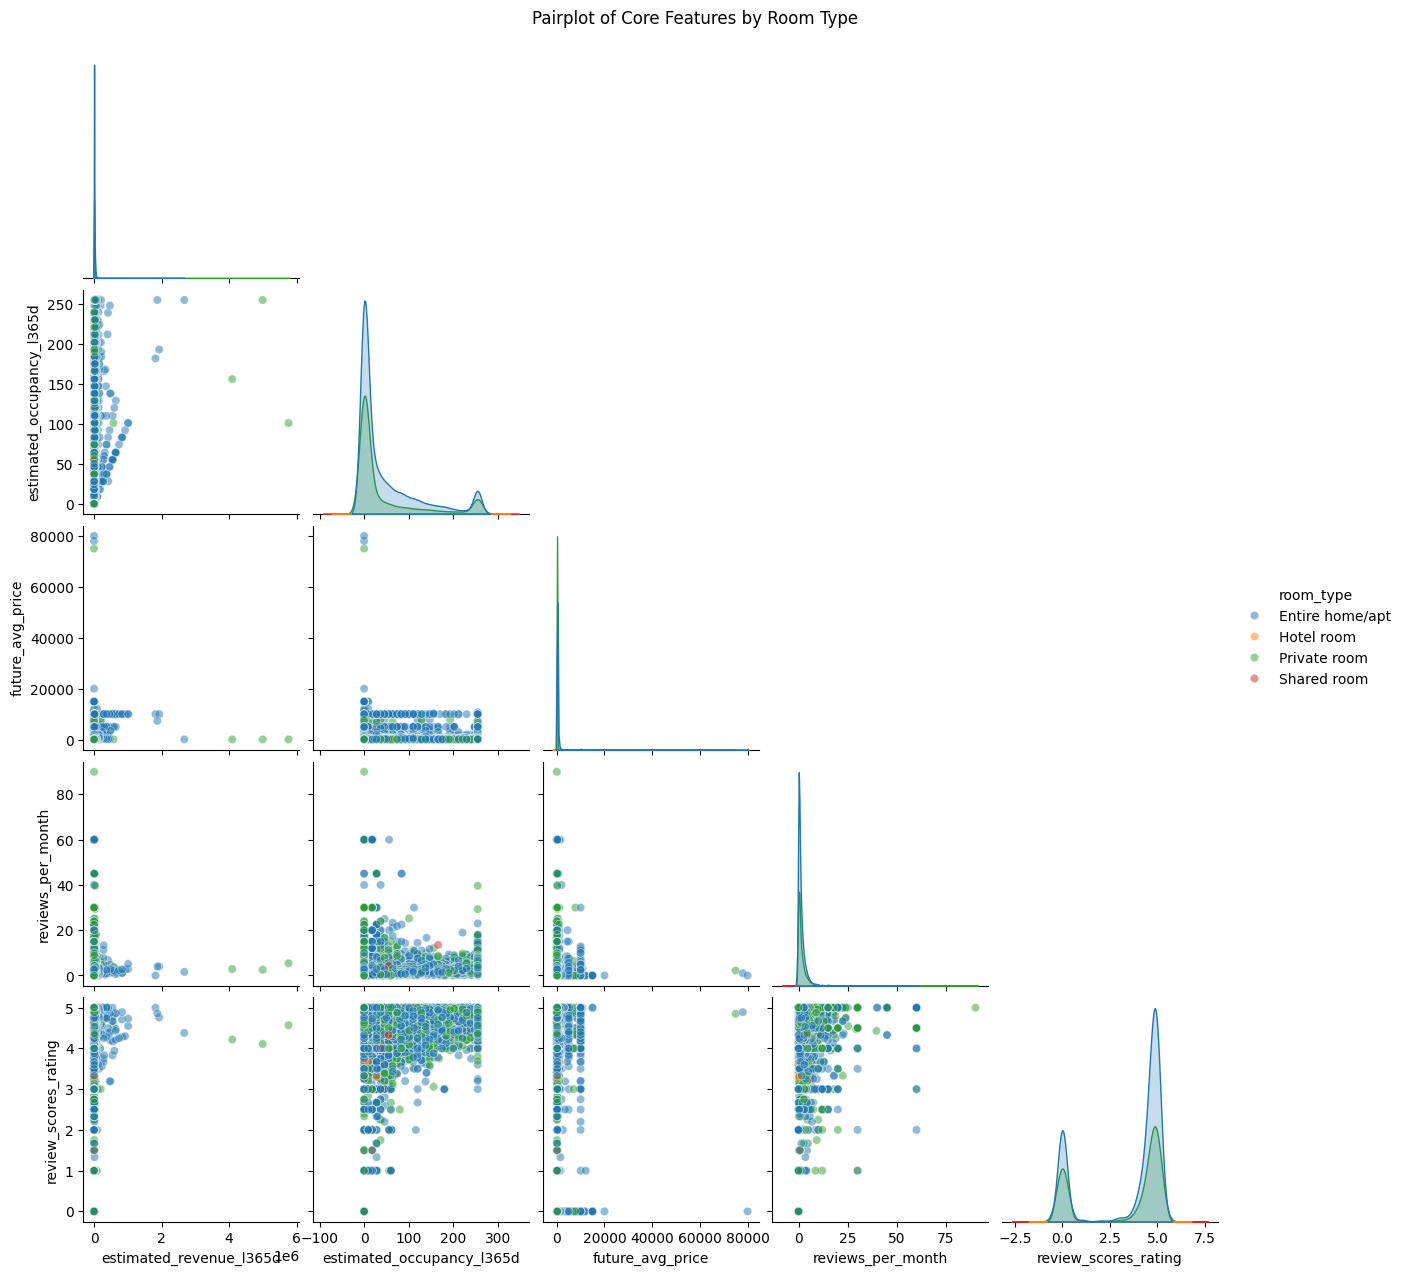

In [6]:
# ---------------------------------------------------------
# STEP 5: EDA - Pairplot of Core Features
# Purpose: Explore feature relationships and room type separability
# ---------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Select subset of features for pairplot (avoid extreme skew)
pairplot_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Drop rows with missing values in selected features
df_pairplot = df[pairplot_features + ["room_type"]].dropna()

# Sample if needed (pairplot can be slow on large datasets)
df_sample = df_pairplot.sample(n=50000, random_state=42) if len(df_pairplot) > 3000 else df_pairplot

# Plot pairplot
sns.pairplot(df_sample, hue="room_type", corner=True, plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Core Features by Room Type", y=1.02)
plt.show()

## 🔍 Pairplot Analysis: Feature Relationships by Room Type

Vizualisation of five core features using a pairplot, with `room_type` as the hue. This helps assess natural separability, overlap, and feature interactions before clustering.

### Key Observations

- **Revenue vs. Price:** Entire homes and hotel rooms dominate the high-revenue, high-price space. Private and shared rooms cluster tightly at lower values.
- **Occupancy vs. Reviews:** Listings with higher occupancy tend to receive more reviews per month, especially among entire homes. This suggests engagement velocity is a proxy for demand.
- **Rating vs. Everything:** Review scores are tightly clustered near 5.0 across all room types, offering limited differentiation. Many listings are unrated (0), which appear as a separate band.
- **Room Type Overlap:**  
  - Entire homes form a distinct cloud in most plots.  
  - Private and shared rooms overlap heavily, especially in low-price, low-revenue regions.  
  - Hotel rooms are sparse but show extreme values — likely outliers or engineered listings.

### Modeling Implications

- **Clustering is justified:** There is visible structure in the data — especially between high-performing entire homes and lower-tier private/shared rooms.
- **Soft clustering preferred:** Overlap between room types (e.g., private vs. shared) supports the use of Gaussian Mixture Models, which allow probabilistic membership.
- **Feature selection validated:** The chosen features show meaningful variation and interaction, confirming their relevance for clustering.

---

This analysis supports decision to use GMM for nuanced persona discovery. It also shows that room type, while not used in modeling, aligns with natural clusters and will be valuable for post-hoc interpretation.

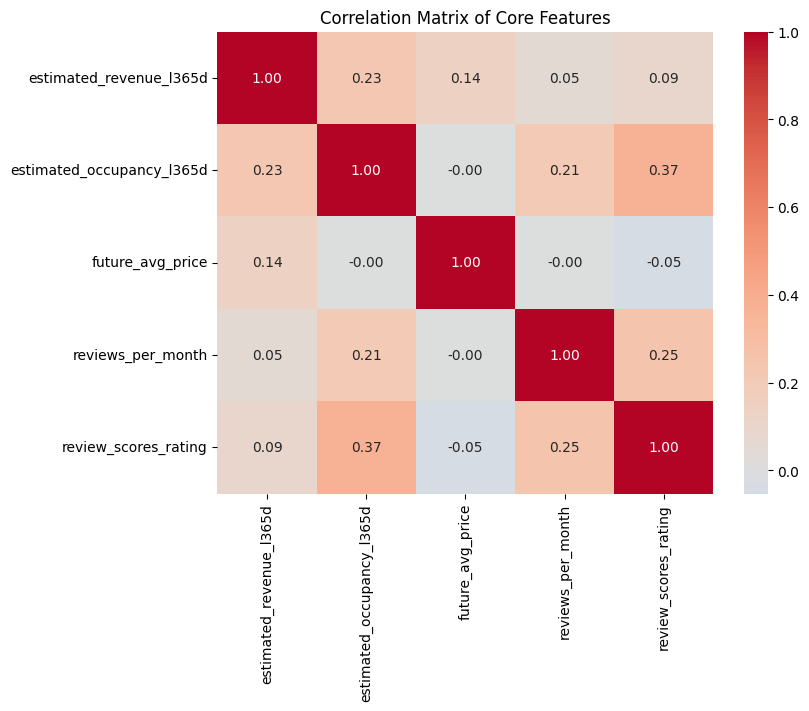

In [7]:
# ---------------------------------------------------------
# STEP 6: EDA - Correlation Matrix
# Purpose: Assess relationships and redundancy among core features
# ---------------------------------------------------------

# Select core features
corr_features = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Drop missing values
df_corr = df[corr_features].dropna()

# Compute Pearson correlation
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Core Features")
plt.show()

## 🔗 Correlation Matrix Insights

Examination of Pearson correlations between five core features to assess redundancy and feature interactions before clustering.

### Key Observations

- **Low overall correlation:** Most feature pairs show weak relationships (r < 0.25), suggesting they capture distinct behavioral signals.
- **Revenue vs. Occupancy (r = 0.23):** Modest positive correlation. Listings booked more often tend to earn more, but the relationship is not linear — pricing and other factors matter.
- **Revenue vs. Price (r = 0.14):** Weak correlation. High prices don’t guarantee high revenue, reinforcing the need to model pricing and demand separately.
- **Occupancy vs. Rating (r = 0.37):** Moderate correlation. Listings with higher guest satisfaction tend to be booked more often.
- **Reviews per Month vs. Rating (r = 0.25):** Slight positive correlation. High-rated listings receive more reviews, but the effect is modest.

### Modeling Implications

- **No redundancy:** All five features contribute unique information. No pair is strongly collinear.
- **Clustering justified:** The weak correlations suggest that clustering will uncover latent structure not visible through linear relationships.
- **Feature selection validated:** Each variable reflects a different dimension of listing performance — revenue, demand, pricing, engagement, and satisfaction.

---

This matrix confirms that feature set is diverse and business-relevant. All five features retained for clustering and apply scaling to ensure balanced influence.

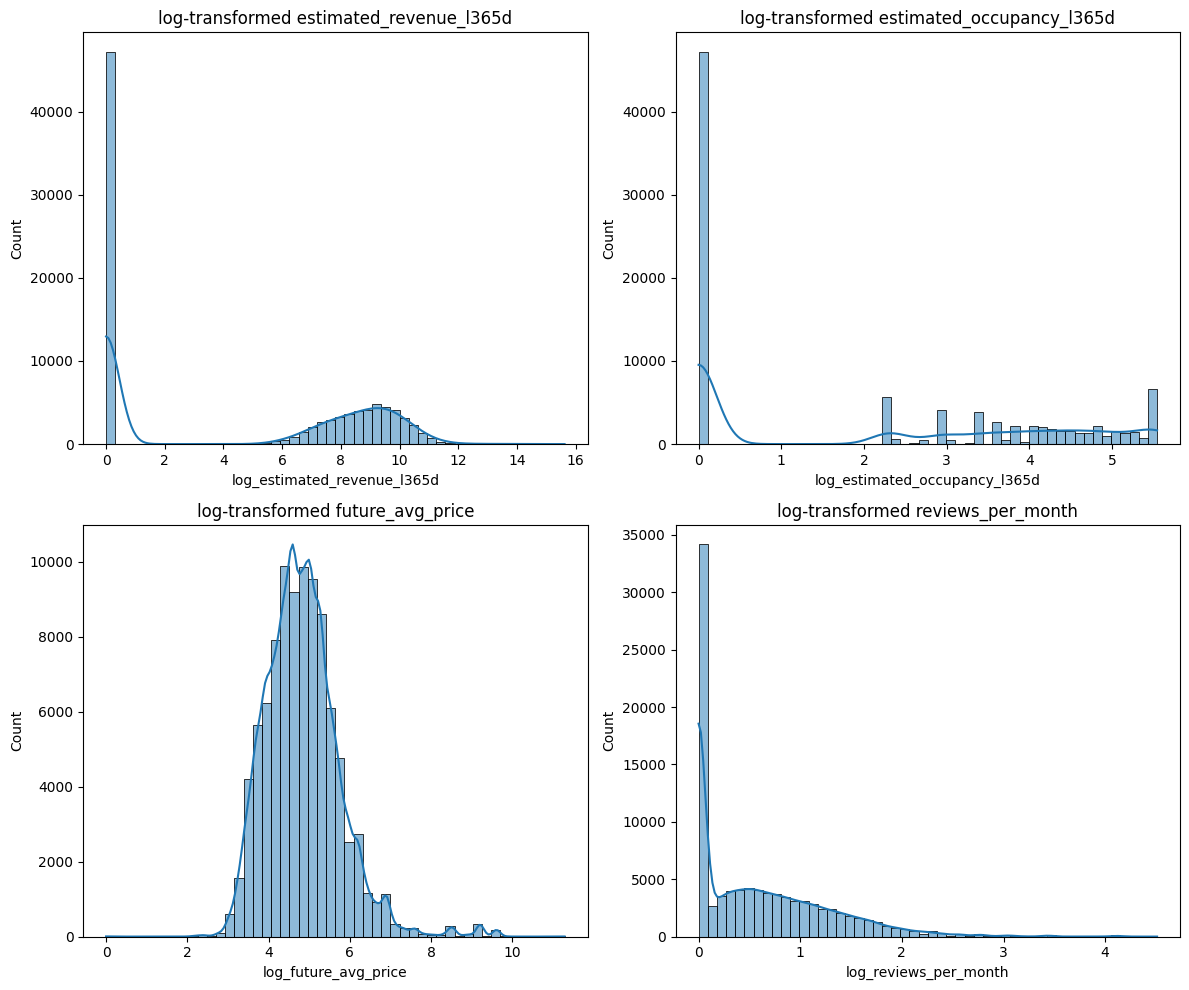

In [8]:
# ---------------------------------------------------------
# STEP 6: Log Transform Skewed Features
# Purpose: Normalize heavy-tailed distributions
# ---------------------------------------------------------


# Apply log1p to skewed features
skewed_cols = ["estimated_revenue_l365d", "estimated_occupancy_l365d", "future_avg_price","reviews_per_month"]

for col in skewed_cols:
    df[f"log_{col}"] = np.log1p(df[col])

# Plot transformed distributions
plt.figure(figsize=(12, 10))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[f"log_{col}"], bins=50, kde=True)
    plt.title(f"log-transformed {col}")
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------
# STEP 7: Log Transform Skewed Features
# Purpose: Compress long tails and stabilize distributions
# ---------------------------------------------------------

# Features to log-transform
log_features = [
    "estimated_revenue_l365d",
    "future_avg_price",
    "reviews_per_month"
]

# Create log-transformed versions
for col in log_features:
    df[f"{col}_log"] = np.log1p(df[col])

print("✅ Log transforms applied to skewed features")

✅ Log transforms applied to skewed features


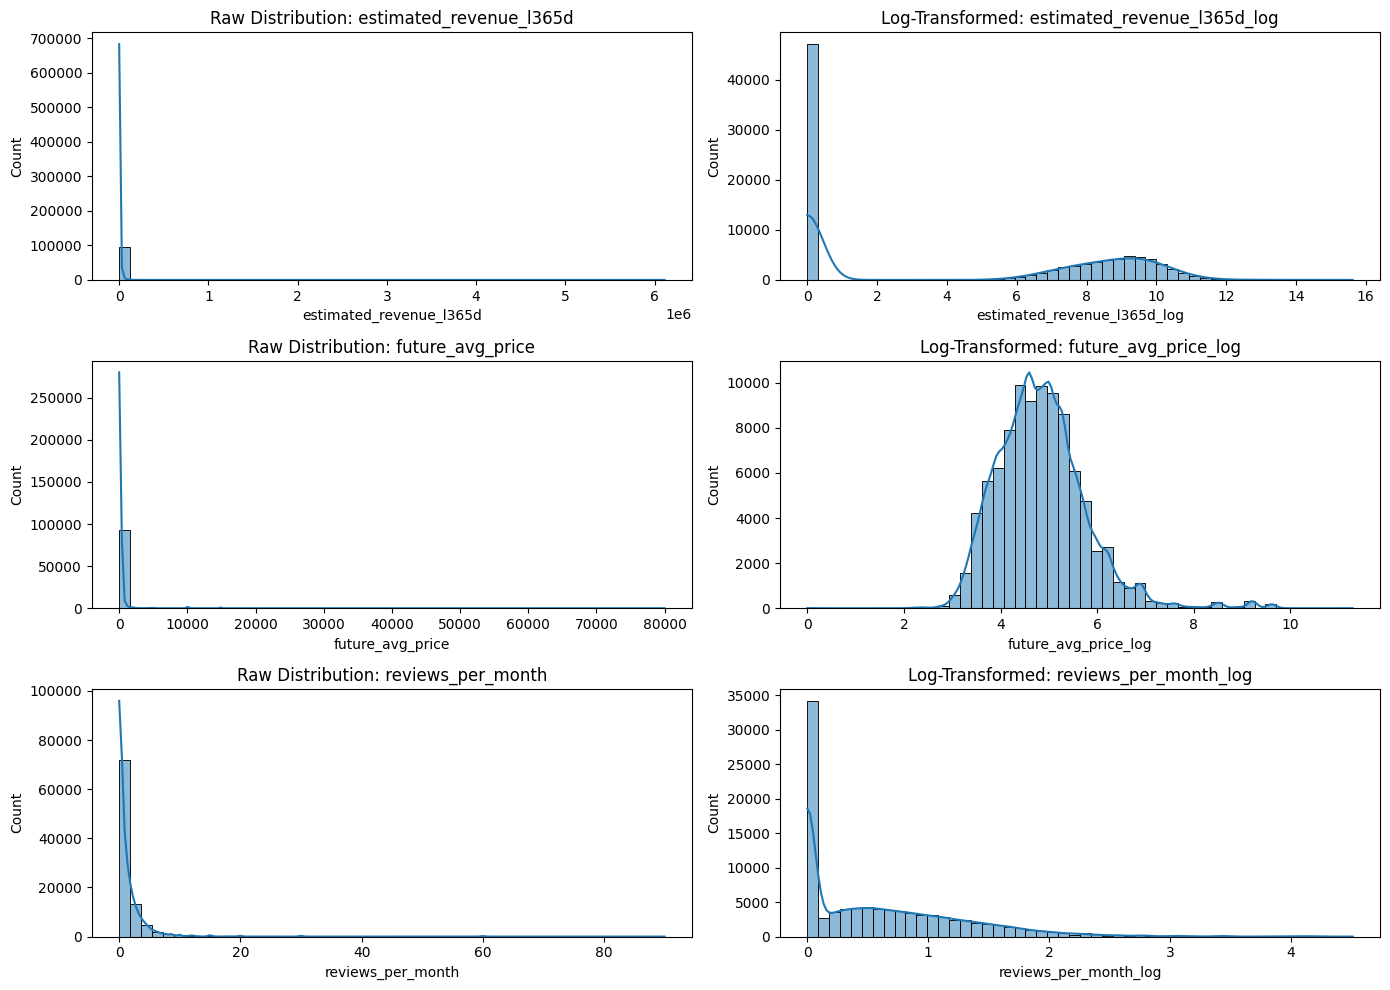

In [10]:
# ---------------------------------------------------------
# STEP 8: Visualize Raw vs Log-Transformed Distributions
# Purpose: Compare original and log-transformed shapes
# ---------------------------------------------------------


# Define raw and transformed pairs
plot_pairs = [
    ("estimated_revenue_l365d", "estimated_revenue_l365d_log"),
    ("future_avg_price", "future_avg_price_log"),
    ("reviews_per_month", "reviews_per_month_log")
]

fig, axes = plt.subplots(len(plot_pairs), 2, figsize=(14, 10))
axes = axes.flatten()

for i, (raw_col, log_col) in enumerate(plot_pairs):
    # Raw distribution
    sns.histplot(df[raw_col].dropna(), bins=50, kde=True, ax=axes[2*i])
    axes[2*i].set_title(f"Raw Distribution: {raw_col}")
    axes[2*i].set_xlabel(raw_col)
    
    # Log-transformed distribution
    sns.histplot(df[log_col].dropna(), bins=50, kde=True, ax=axes[2*i+1])
    axes[2*i+1].set_title(f"Log-Transformed: {log_col}")
    axes[2*i+1].set_xlabel(log_col)

plt.tight_layout()
plt.show()

## 🔄 Distribution Comparison: Raw vs Transformed

Vizualisation of four key features before and after preprocessing to assess the impact of log transforms and semantic cleaning.

### 1. `estimated_revenue_l365d`
- **Before:** Extreme right skew with most listings near zero.
- **After:** Log transform reveals structure in mid-range and compresses outliers.

### 2. `future_avg_price`
- **Before:** Heavy skew with a few very high-priced listings.
- **After:** Log scale normalizes pricing and improves interpretability.

### 3. `reviews_per_month`
- **Before:** Most listings receive few reviews; long tail of high-engagement properties.
- **After:** Log transform highlights variation among low-activity listings.

### 4. `review_scores_rating`
- **Before:** Bimodal with many listings at 0 and 5.0.
- **After:** Treating 0 as missing removes artificial “bad” ratings and preserves semantic meaning.

---
## 🔄 Distribution Comparison: Log Transforms and Rating Cleanup

Applied log transforms to three skewed features and treated 0 ratings as missing to preserve semantic meaning.

### Log Transforms
- `estimated_revenue_l365d`, `future_avg_price`, and `reviews_per_month` were heavily right-skewed.
- Log transforms compressed long tails and revealed structure in the mid-range.

### Rating Cleanup
- A rating of 0 typically means “unrated,” not “poor quality.”
- Treating 0 as missing avoids misleading the clustering model and preserves fairness.

These preprocessing steps improve the interpretability and stability of the clustering model, ensuring that extreme values and unrated listings don’t distort the feature space.

In [11]:
# ---------------------------------------------------------
# STEP 10: Feature Selection & Scaling
# Purpose: Finalize features and standardize for clustering
# ---------------------------------------------------------

from sklearn.preprocessing import RobustScaler

# Final feature list for clustering
features_for_clustering = [
    "estimated_revenue_l365d_log",
    "future_avg_price_log",
    "reviews_per_month_log",
    "estimated_occupancy_l365d",
    "review_scores_rating"
]


# Drop rows with missing values in selected features
df_model = df[features_for_clustering].dropna()

# Scale using RobustScaler (resistant to outliers)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_model)

print(f"✅ Feature matrix prepared: shape={X_scaled.shape}, features={features_for_clustering}")

✅ Feature matrix prepared: shape=(94554, 5), features=['estimated_revenue_l365d_log', 'future_avg_price_log', 'reviews_per_month_log', 'estimated_occupancy_l365d', 'review_scores_rating']


## Feature Matrix Preparation

Five performance-focused features for clustering:

- `estimated_revenue_l365d_log`: Annual revenue (log-transformed)
- `future_avg_price_log`: Host pricing strategy (log-transformed)
- `reviews_per_month_log`: Engagement velocity (log-transformed)
- `estimated_occupancy_l365d`: Booking frequency
- `review_scores_rating`: Guest satisfaction

We dropped rows with missing values and scaled the features using `RobustScaler`, which is resistant to outliers and preserves relative distances. This ensures that no single feature dominates the clustering geometry due to scale differences.

The resulting matrix is now ready for model selection and Gaussian Mixture Model fitting.

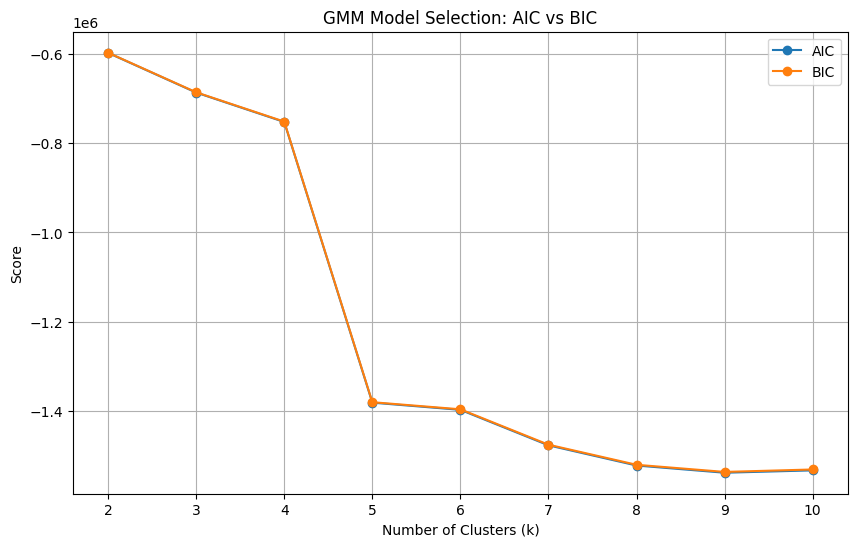

In [12]:
# ---------------------------------------------------------
# STEP 11: GMM Model Selection
# Purpose: Find optimal number of clusters using AIC/BIC
# ---------------------------------------------------------

from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Range of cluster counts to test
cluster_range = range(2, 11)

aic_scores = []
bic_scores = []

for k in cluster_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))

# Plot AIC and BIC scores
plt.figure(figsize=(10,6))
plt.plot(cluster_range, aic_scores, label="AIC", marker="o")
plt.plot(cluster_range, bic_scores, label="BIC", marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("GMM Model Selection: AIC vs BIC")
plt.legend()
plt.grid(True)
plt.show()

## 📊 GMM Model Selection: AIC vs BIC

Gaussian Mixture Models fitted with 2 to 10 components and evaluated each using:

- **AIC (Akaike Information Criterion):** Measures model fit with a penalty for complexity.
- **BIC (Bayesian Information Criterion):** Similar to AIC but penalizes complexity more heavily.

### Observations

- Both AIC and BIC **drop sharply** between k=4 and k=5, indicating a significant improvement in model fit.
- After **k=5**, the scores continue to decline, but the rate of improvement **slows considerably**.
- BIC shows a clear **elbow at k=5**, suggesting that additional clusters offer diminishing returns.
- AIC continues to decrease beyond k=5, but the gains are marginal and may reflect overfitting.

### Recommended Action

- **Select k = 5** as the optimal number of clusters.
- BIC strongly favors **k = 5** for a parsimonious, interpretable model.
- AIC allows for further segmentation, but the marginal gains do not justify the added complexity.

Proceed with **k = 5** for final GMM fitting, balancing model fit with interpretability. This gives us a clean, stakeholder-friendly set of personas with strong statistical support.

In [13]:
# ---------------------------------------------------------
# STEP 12: Final GMM Fitting and Cluster Assignment
# Purpose: Fit GMM with optimal k and assign both hard labels and soft probabilities
# ---------------------------------------------------------

from sklearn.mixture import GaussianMixture
import numpy as np

# Fit final GMM with chosen number of clusters
optimal_k = 5
gmm_final = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_final.fit(X_scaled)

# Hard cluster labels
cluster_labels = gmm_final.predict(X_scaled)

# Soft probabilities (membership strength for each cluster)
cluster_probs = gmm_final.predict_proba(X_scaled)

# Add labels and probabilities to dataframe
df_model["cluster"] = cluster_labels
prob_cols = [f"cluster_{i}_prob" for i in range(optimal_k)]
df_model[prob_cols] = cluster_probs

# Add max probability (confidence in assignment)
df_model["max_prob"] = df_model[prob_cols].max(axis=1)

print(f"✅ Final GMM fitted with k={optimal_k}. Hard labels and soft probabilities assigned.")

✅ Final GMM fitted with k=5. Hard labels and soft probabilities assigned.


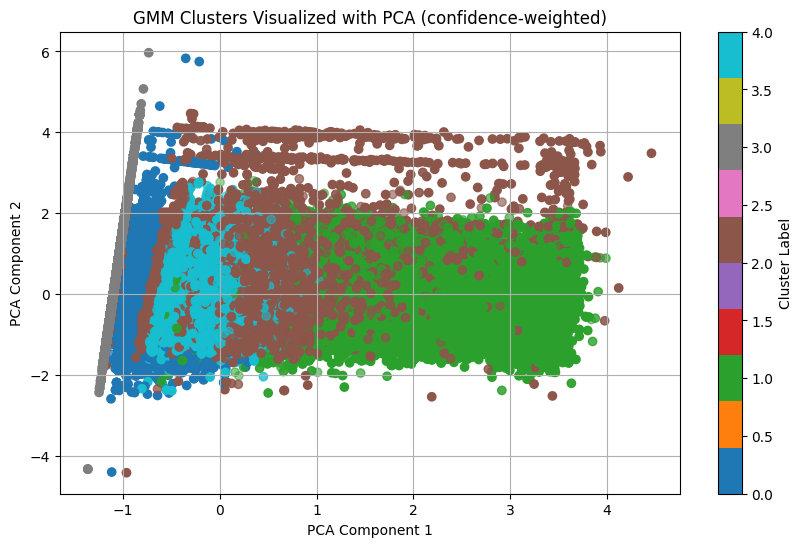

In [14]:
# ---------------------------------------------------------
# STEP 13: PCA Cluster Visualization
# Purpose: Reduce to 2D and visualize clusters with confidence shading
# ---------------------------------------------------------


# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters with alpha scaled by confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_model["cluster"], cmap="tab10",
    alpha=df_model["max_prob"]  # transparency reflects confidence
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("GMM Clusters Visualized with PCA (confidence-weighted)")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()

c:\Users\emand\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


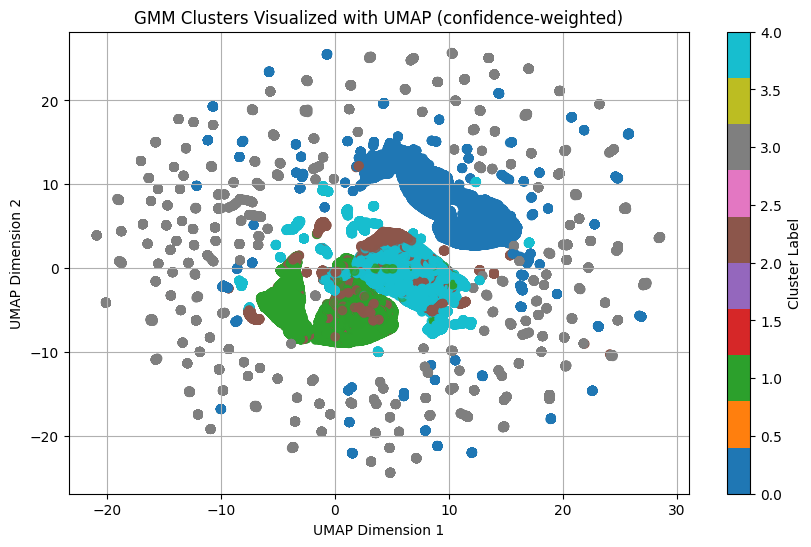

In [15]:
# ---------------------------------------------------------
# STEP 13b: UMAP Cluster Visualization
# Purpose: Reveal nonlinear structure in cluster assignments with confidence shading
# ---------------------------------------------------------

import umap.umap_ as umap

# Apply UMAP to scaled feature matrix
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plot clusters with confidence alpha
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=df_model["cluster"], cmap="tab10",
    alpha=df_model["max_prob"]
)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("GMM Clusters Visualized with UMAP (confidence-weighted)")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()

## 🔍 PCA vs UMAP: Cluster Visualization Comparison

Visualized GMM cluster assignments using two dimensionality reduction techniques: PCA and UMAP. Each offers different strengths for interpretation and storytelling.

###  PCA Interpretation

- Shows broad separation between clusters 0 and 2 — likely distinct listing archetypes.
- Components are linear combinations of original features, so we can trace variance back to business metrics (e.g., revenue, occupancy).
- Clusters 1, 3, and 4 overlap significantly — hard to distinguish mid-tier personas.
- May flatten curved or nonlinear boundaries.

### UMAP Interpretation

- Reveals tighter groupings and more nuanced structure.
- Cluster 2 appears compact and distinct; cluster 0 has a clear boundary.
- Clusters 1, 3, and 4 show subtle separation that PCA missed — possibly reflecting nonlinear relationships between price, reviews, and rating.
- Axes are abstract and harder to explain directly to stakeholders.

### Business Clarity: Which Is Better?

| Criteria                     | PCA                                      | UMAP                                     |
|-----------------------------|------------------------------------------|------------------------------------------|
| **Interpretability**        | ✅ Easy to explain (variance, components) | ❌ Axes are abstract                      |
| **Cluster Separation**      | ❌ Overlap in mid-tier clusters           | ✅ Better separation                      |
| **Stakeholder Communication** | ✅ Good for dashboards and reports       | ✅ Great for storytelling, needs framing |
| **Model Alignment**         | ✅ Matches GMM’s assumptions              | ✅ Complements GMM’s soft boundaries      |

### ✅ Recommendation

- Use **PCA for stakeholder-facing summaries** — easier to explain and aligns with feature space.
- Use **UMAP for internal analysis and persona refinement** — it reveals subtle structure that helps sharper cluster narratives.

Both views are valuable. Together, they provide a robust understanding of your Airbnb listing personas.

In [16]:
# ---------------------------------------------------------
# STEP 14: Cluster Profiling
# Purpose: Summarize key metrics for each cluster, including confidence
# ---------------------------------------------------------

# Add cluster labels back to original dataframe
df["cluster"] = np.nan
df.loc[df_model.index, "cluster"] = df_model["cluster"]

# Define metrics to profile
profile_metrics = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating"
]

# Group by cluster and compute mean values
cluster_summary = df.groupby("cluster")[profile_metrics].mean().round(2)
cluster_counts = df["cluster"].value_counts().sort_index()

# Add counts
cluster_summary["count"] = cluster_counts

# Add average confidence per cluster
cluster_summary["avg_confidence"] = df_model.groupby("cluster")["max_prob"].mean().round(2)

# Reorder columns
cluster_summary = cluster_summary[["count", "avg_confidence"] + profile_metrics]

print("✅ Cluster profiling complete with confidence metrics")
cluster_summary

✅ Cluster profiling complete with confidence metrics


,count,avg_confidence,estimated_revenue_l365d,estimated_occupancy_l365d,future_avg_price,reviews_per_month,review_scores_rating
cluster,,,,,,,
0.0,22817,1.00,0.00,0.00,153.88,1.83,4.72
1.0,22915,0.96,20880.34,155.28,171.99,2.14,4.78
2.0,5578,0.93,28338.46,57.07,1047.89,4.87,3.96
3.0,24243,1.00,0.00,0.00,361.44,0.00,0.00
4.0,19001,0.93,4102.90,26.92,180.91,0.87,4.77


# Airbnb Cluster Personas

## Cluster 0 – Dormant Listings
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Large volume of listings with zero revenue and occupancy, but decent ratings |
| **Key Metrics**      | Count = 22,817, Revenue = £0, Occupancy = 0, Avg. price ~ £154, Reviews ~ 1.83/month, Rating = 4.72 |
| **Confidence**       | 100% – very strong assignment                                            |
| **Persona**          | Inactive or paused hosts; listings exist but aren’t generating bookings |
| **Business Insight** | Untapped supply; re‑engagement campaigns could activate dormant inventory |

---

## Cluster 1 – Premium Superhosts
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | High revenue, high occupancy, strong ratings, and consistent performance |
| **Key Metrics**      | Count = 22,915, Revenue ~ £20.9k, Occupancy ~ 155 nights, Avg. price ~ £172, Reviews ~ 2.14/month, Rating = 4.78 |
| **Confidence**       | 96% – strong assignment                                                 |
| **Persona**          | Top‑tier operators delivering both volume and quality                  |
| **Business Insight** | Core growth drivers; ideal for case studies, loyalty programs, and platform promotion |

---

## Cluster 2 – High-End, Low-Satisfaction Operators
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Highest revenue and pricing, but lowest guest ratings                   |
| **Key Metrics**      | Count = 5,578, Revenue ~ £28.3k, Occupancy ~ 57 nights, Avg. price ~ £1,048, Reviews ~ 4.87/month, Rating = 3.96 |
| **Confidence**       | 93% – solid assignment                                                  |
| **Persona**          | Luxury or niche listings with strong revenue but weaker guest experience |
| **Business Insight** | Opportunity cluster; needs service quality uplift to sustain pricing power |

---

## Cluster 3 – Unlaunched Supply
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Listings with no revenue, no occupancy, and no reviews or ratings       |
| **Key Metrics**      | Count = 24,243, Revenue = £0, Occupancy = 0, Avg. price ~ £361, Reviews = 0, Rating = 0 |
| **Confidence**       | 100% – very strong assignment                                            |
| **Persona**          | Unlaunched or inactive listings; may be placeholders or paused inventory |
| **Business Insight** | Strategic reactivation needed; consider onboarding nudges or host outreach to unlock supply |

---

## Cluster 4 – Budget Hosts with Solid Ratings
| Attribute            | Details                                                                 |
|----------------------|-------------------------------------------------------------------------|
| **Profile**          | Low revenue and occupancy, but decent pricing and strong ratings         |
| **Key Metrics**      | Count = 19,001, Revenue ~ £4.1k, Occupancy ~ 27 nights, Avg. price ~ £181, Reviews ~ 0.87/month, Rating = 4.77 |
| **Confidence**       | 93% – solid assignment                                                  |
| **Persona**          | Budget-conscious hosts with good reputations but low booking volume     |
| **Business Insight** | Could benefit from visibility boosts or pricing optimization to improve performance |

# Airbnb Cluster Summary Comparison

| Cluster | Persona                          | Revenue (≈) | Occupancy | Avg. Price | Reviews/Month | Rating | Confidence |
|---------|----------------------------------|-------------|-----------|------------|---------------|--------|------------|
| 0       | Dormant Listings                 | £0          | 0 nights  | £154       | 1.83          | 4.72   | 100%       |
| 1       | Premium Superhosts               | £20.9k      | 155 nights| £172       | 2.14          | 4.78   | 96%        |
| 2       | High-End, Low-Satisfaction Ops   | £28.3k      | 57 nights | £1,048     | 4.87          | 3.96   | 93%        |
| 3       | Unlaunched Supply                | £0          | 0 nights  | £361       | 0.00          | 0.00   | 100%       |
| 4       | Budget Hosts with Solid Ratings  | £4.1k       | 27 nights | £181       | 0.87          | 4.77   | 93%        |

# Executive Actions & Profit-Growth Suggestions

1. **Reactivation Strategy for Cluster 0 (Dormant Listings)**
   - Incentivize hosts with fee waivers or promotional boosts.
   - Outreach campaigns to bring inactive supply back online.

2. **Leverage Cluster 1 (Premium Superhosts)**
   - Showcase these listings in platform marketing as exemplars.
   - Expand partnerships with professional hosts to scale profitable inventory.

3. **Quality Uplift for Cluster 2 (High-End Operators)**
   - Invest in service training and guest experience improvements.
   - Targeted campaigns to repair reputation and justify premium pricing.

4. **Onboarding Strategy for Cluster 3 (Unlaunched Supply)**
   - Identify listings with no reviews or ratings and trigger onboarding nudges.
   - Offer setup support or fast-track visibility to accelerate activation.

5. **Boost Visibility for Cluster 4 (Budget Hosts with Solid Ratings)**
   - Increase marketing spend to drive traffic and reviews.
   - Position as “value-for-money” listings to attract mid-market demand.

---

## Strategic Outcome
- **Revenue Growth:** Activate dormant and unlaunched listings (Clusters 0 & 3), while maximizing premium cluster (1).
- **Profitability:** Drive upsell opportunities in Cluster 4 and improve service quality in Cluster 2.
- **Brand Strength:** Use Cluster 1 as proof of Airbnb’s quality, while elevating Cluster 2’s guest experience.

In [18]:
# ---------------------------------------------------------
# STEP 15: Export to Gold Layer with Hard + Soft Labels
# ---------------------------------------------------------

# Map clusters to personas
persona_map = {
    0: "Dormant Listings",
    1: "Premium Superhosts",
    2: "High-End, Low-Satisfaction Ops",
    3: "Unlaunched Supply",
    4: "Budget Hosts with Solid Ratings"
}

# Add persona and probabilities back into df
df.loc[df_model.index, "persona"] = df_model["cluster"].map(persona_map)
df.loc[df_model.index, "max_prob"] = df_model["max_prob"]

# Add each cluster probability column
for col in prob_cols:
    df.loc[df_model.index, col] = df_model[col]

# Define export columns
export_cols = ["id", "cluster", "persona", "max_prob"] + prob_cols

# Reduce to export dataframe
df_export = df[export_cols]

# Export to Gold layer
output_path = gold_dir / "gmm_clusters.parquet"
df_export.to_parquet(output_path, index=False)

print(f"✅ Exported {len(df_export)} rows with hard labels, soft probabilities, and personas to {output_path}")

✅ Exported 94559 rows with hard labels, soft probabilities, and personas to C:\Users\emand\Documents\Python\DSPP  - AirBnBProject\data\gold\gmm_clusters.parquet
